# PUBG: BATTLEGROUNDS -- playerbase over time, via Steam reviews

**Purpose:** `collectors/steam_review_history_pull.py`'s first real crawl
(completed 2026-09-13, 536,953 reviews) gives this project its first
look at a title's *playerbase* over time, as distinct from its Twitch
*viewership* -- owners who bothered to write a review, not streamers or
the people watching them. That's a genuinely different population from
everything else in this project.

**Critical scope correction, confirmed live while building this
notebook, not assumed from a clean crawl exit:** this is NOT PUBG's
full history since its 2017-12-21 release. Steam's own
`query_summary.total_reviews` for this app is **2,753,749** -- the
crawl reached only **536,953 (19.5%)**, back to **2023-12-25**, before
`filter=recent`'s cursor pagination stopped advancing (a real,
undocumented depth cap for very-high-review-count titles, not a bug in
this collector -- see `collectors/steam_review_history_pull.py`'s own
docstring). Everything below covers **late December 2023 to September
2026, roughly 2.75 years** -- PUBG's recent era, not its full lifetime.

In [1]:
import sys
from pathlib import Path
from datetime import datetime, timezone

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from etl.db import get_connection
from analysis.fandom_region_decomposition import (
    calibrate_timezone_curve,
    decompose_by_timezone,
    get_steam_review_hourly_series,
    load_subjects,
)

conn = get_connection()
subject = load_subjects()["pubg"]
calibration_curve = calibrate_timezone_curve(conn)

review_rows = conn.execute(
    "SELECT timestamp_created, language FROM steam_review_history WHERE subject_id = 'pubg'"
).fetchall()
reviews_df = pd.DataFrame(review_rows, columns=["timestamp_created", "language"])
reviews_df["dt"] = pd.to_datetime(reviews_df["timestamp_created"], unit="s", utc=True)
reviews_df["month"] = reviews_df["dt"].dt.to_period("M")
reviews_df["quarter"] = reviews_df["dt"].dt.to_period("Q")

print(f"{len(reviews_df)} reviews, {reviews_df['dt'].min()} to {reviews_df['dt'].max()}")

536953 reviews, 2023-12-25 15:01:03+00:00 to 2026-09-13 08:07:31+00:00


/tmp/ipykernel_44023/1578714005.py:35: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reviews_df["month"] = reviews_df["dt"].dt.to_period("M")
/tmp/ipykernel_44023/1578714005.py:36: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  reviews_df["quarter"] = reviews_df["dt"].dt.to_period("Q")


## Review volume over time

**Caveat before reading this as a playerbase-size proxy**: review volume
is also a function of Steam's own review-prompt UI, sale/free-weekend
spikes, and major-update cycles -- not a clean 1:1 read of concurrent
players. Treat spikes as "something drove more people to write reviews
this month," not automatically "the playerbase grew this month."

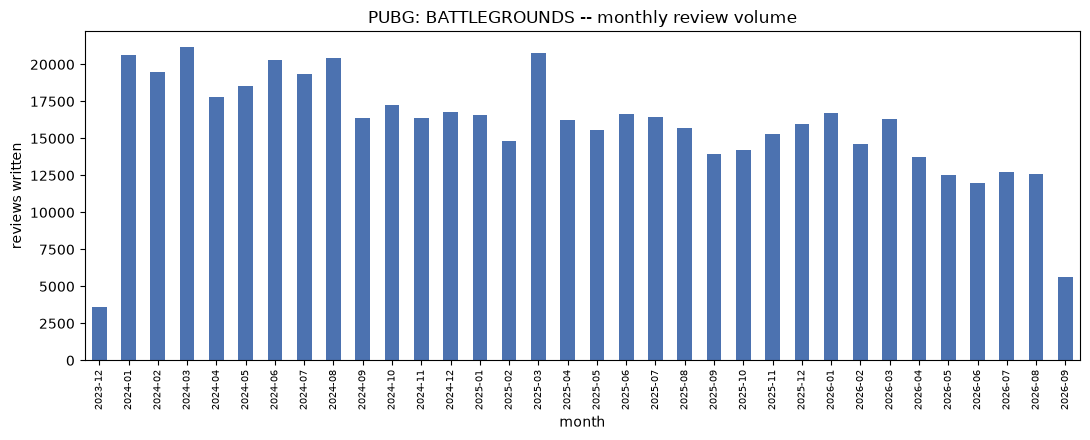

count       34.000000
mean     15792.735294
std       3787.929084
min       3616.000000
25%      14324.750000
50%      16325.000000
75%      17657.250000
max      21175.000000
dtype: float64

In [2]:
monthly_volume = reviews_df.groupby("month").size()
fig, ax = plt.subplots(figsize=(11, 4.5))
monthly_volume.plot(kind="bar", ax=ax, color="#4c72b0")
ax.set_ylabel("reviews written")
ax.set_title("PUBG: BATTLEGROUNDS -- monthly review volume")
ax.set_xticklabels([str(p) for p in monthly_volume.index], rotation=90, fontsize=7)
plt.tight_layout()
plt.show()
monthly_volume.describe()

## Language mix over time

Top 6 languages by total volume over the whole window, "other" collapsing
the rest -- same bucketing convention `niche_membership.ipynb` uses for
its own top-languages table. Normalized to a monthly SHARE, not a count,
so a change in total review volume (previous chart) doesn't get mistaken
for a change in composition.

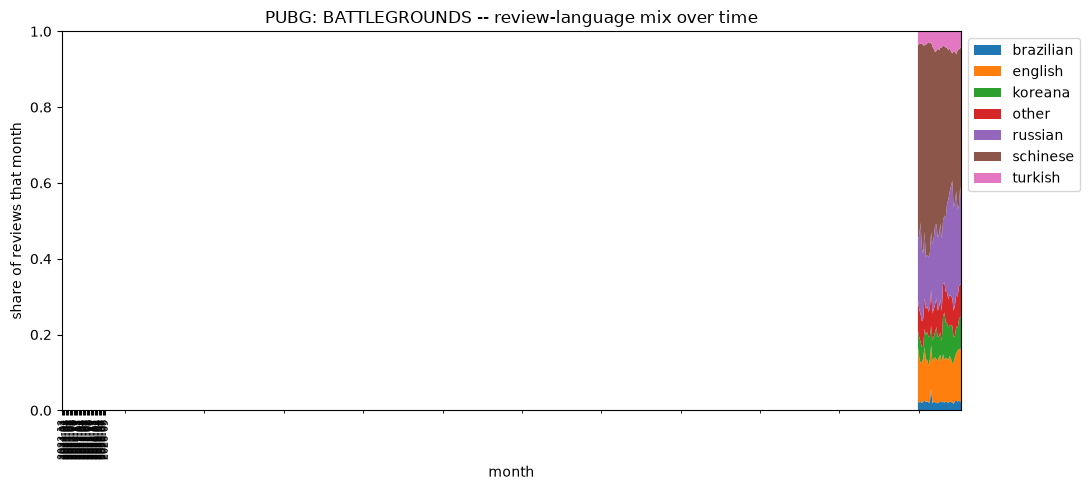

lang_bucket,brazilian,english,koreana,other,russian,schinese,turkish
month,,,,,,,
2026-04,2.6,11.6,5.6,7.9,27.2,39.8,5.2
2026-05,2.6,12.6,7.2,8.5,27.1,36.0,6.0
2026-06,2.5,13.4,5.9,8.2,23.2,42.0,4.8
2026-07,2.7,13.7,7.7,8.7,21.4,41.1,4.7
2026-08,2.4,13.9,8.6,8.7,25.6,36.7,4.1
2026-09,2.6,14.2,7.6,8.4,22.0,40.7,4.6


In [3]:
top_languages = reviews_df["language"].value_counts().head(6).index.tolist()
reviews_df["lang_bucket"] = reviews_df["language"].where(reviews_df["language"].isin(top_languages), "other")

monthly_lang = reviews_df.groupby(["month", "lang_bucket"]).size().unstack(fill_value=0)
monthly_lang_share = monthly_lang.div(monthly_lang.sum(axis=1), axis=0)

fig, ax = plt.subplots(figsize=(11, 5))
monthly_lang_share.plot(kind="area", stacked=True, ax=ax, linewidth=0)
ax.set_ylabel("share of reviews that month")
ax.set_title("PUBG: BATTLEGROUNDS -- review-language mix over time")
ax.set_xticks(range(len(monthly_lang_share.index)))
ax.set_xticklabels([str(p) for p in monthly_lang_share.index], rotation=90, fontsize=7)
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

(monthly_lang_share * 100).round(1).tail(6)

## English-speaking regional decomposition, over time

Same `decompose_by_timezone` method as `notebooks/
english_fandom_decomposition.ipynb`, applied per quarter instead of once
over the whole window -- possible here specifically because
`steam_review_history` spans multiple years for this subject, unlike
Twitch's ~2-week `language_mix_snapshots` coverage.

In [4]:
quarters = sorted(reviews_df["quarter"].unique())
english_rows = []
for q in quarters:
    since = int(q.start_time.tz_localize("UTC").timestamp())
    until = int(q.end_time.tz_localize("UTC").timestamp())
    hourly = get_steam_review_hourly_series(conn, subject, language="english", since=since, until=until)
    if hourly.sum() < 30:  # too few English reviews this quarter for a stable decomposition
        continue
    shares = decompose_by_timezone(hourly, calibration_curve=calibration_curve)
    english_rows.append({"quarter": str(q), "english_reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})

english_region_df = pd.DataFrame(english_rows).set_index("quarter")
english_region_df

,english_reviews,US_Canada_East,US_Pacific,UK_Ireland,India,Philippines,Australia_East,Nigeria,South_Africa
quarter,,,,,,,,,
2023Q4,522,17.9,1.3,12.6,18.1,21.8,5.2,4.0,19.2
2024Q1,6733,12.5,0.0,15.3,16.3,22.7,5.4,8.0,19.7
2024Q2,6909,13.6,0.9,10.5,15.7,24.7,7.8,8.8,18.0
2024Q3,5973,13.3,1.5,11.1,14.8,24.5,9.2,8.7,16.9
2024Q4,5688,13.9,3.3,11.8,13.6,23.1,7.9,8.2,18.1
2025Q1,6010,12.4,0.2,13.6,14.1,22.4,6.8,11.2,19.3
2025Q2,5614,12.6,1.7,12.5,14.3,24.5,10.3,5.6,18.4
2025Q3,5446,13.7,0.0,10.5,14.6,22.5,12.2,7.2,19.4
2025Q4,5305,13.3,0.9,10.8,18.1,23.5,8.9,6.5,18.0


## Whole-playerbase regional decomposition, over time

Pooled across ALL languages (`language=None`), against a PUBG-specific
candidate set built from this title's own actual top languages above --
not `CANDIDATE_ENGLISH_COUNTRIES`, since most of PUBG's reviewer base
isn't English-speaking at all. Same non-DST-aware fixed-offset caveat as
everywhere else in this subsystem.

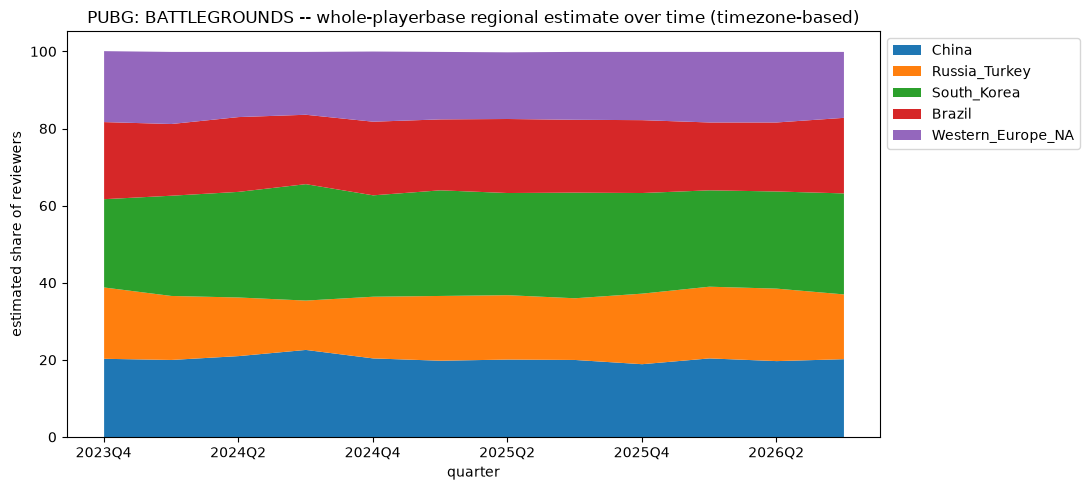

,total_reviews,China,Russia_Turkey,South_Korea,Brazil,Western_Europe_NA
quarter,,,,,,
2023Q4,3616,20.4,18.5,22.9,20.0,18.4
2024Q1,61294,20.1,16.6,26.0,18.6,18.7
2024Q2,56675,21.1,15.2,27.4,19.4,16.9
2024Q3,56168,22.7,12.8,30.2,18.0,16.3
2024Q4,50353,20.5,16.0,26.3,19.1,18.2
2025Q1,52128,19.9,16.8,27.4,18.4,17.5
2025Q2,48413,20.2,16.7,26.5,19.2,17.3
2025Q3,46056,20.1,16.0,27.4,18.9,17.6
2025Q4,45475,19.0,18.3,26.1,18.9,17.7


In [5]:
# Approximate, non-DST-aware UTC offsets matched to PUBG's own top
# review languages (schinese/russian/english/koreana/turkish/brazilian).
# Russia and China each collapsed to one nominal offset despite spanning
# several real timezones -- same simplification
# CALIBRATION_LANGUAGES's docstring already flags for the same reason.
#
# Russia and Turkey merged into one candidate: both UTC+3, genuinely
# indistinguishable by timezone alone -- found live in this notebook's
# first run (their estimated shares alternated between ~17% and 0.0%
# across consecutive quarters with no plausible driver, exactly what an
# unidentifiable pair produces) and is the same collision bug
# CANDIDATE_ENGLISH_COUNTRIES' old US_East/Canada_East pair had (see
# analysis/fandom_region_decomposition.py's module comment). This section
# can only speak to "Russia and Turkey combined," not either alone.
PUBG_CANDIDATE_COUNTRIES = {
    "China": 8.0,
    "Russia_Turkey": 3.0,
    "South_Korea": 9.0,
    "Brazil": -3.0,
    "Western_Europe_NA": 0.0,
}

pooled_rows = []
for q in quarters:
    since = int(q.start_time.tz_localize("UTC").timestamp())
    until = int(q.end_time.tz_localize("UTC").timestamp())
    hourly = get_steam_review_hourly_series(conn, subject, language=None, since=since, until=until)
    if hourly.sum() < 30:
        continue
    shares = decompose_by_timezone(hourly, PUBG_CANDIDATE_COUNTRIES, calibration_curve=calibration_curve)
    pooled_rows.append({"quarter": str(q), "total_reviews": int(hourly.sum()), **{k: round(v * 100, 1) for k, v in shares.items()}})

pooled_region_df = pd.DataFrame(pooled_rows).set_index("quarter")

fig, ax = plt.subplots(figsize=(11, 5))
pooled_region_df.drop(columns="total_reviews").plot(kind="area", stacked=True, ax=ax, linewidth=0)
ax.set_ylabel("estimated share of reviewers")
ax.set_title("PUBG: BATTLEGROUNDS -- whole-playerbase regional estimate over time (timezone-based)")
ax.legend(loc="upper left", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout()
plt.show()

pooled_region_df

## Caveats -- read everything above as directional, not settled

- **This covers late 2023 to now, not PUBG's full 2017 history** -- the
  single most important caveat on this notebook, stated at the top and
  repeated here. Any claim about PUBG's launch-era or mid-life playerbase
  cannot be answered from this data.
- **Review volume is not a clean playerbase-size proxy** -- see the
  volume section's own note. A given month's spike could be a sale, a
  major update, or a review-prompt campaign as easily as organic growth.
- **Timezone deconvolution is directional, not precise** -- calibrated
  off only `ja`/`ko`, fixed non-DST-aware offsets throughout, and the
  whole-playerbase candidate set (`PUBG_CANDIDATE_COUNTRIES`) is a
  judgment call built from this title's own top languages, not a
  general-purpose list.
- **Russia and Turkey cannot be told apart by this method** -- both
  UTC+3, merged into one `Russia_Turkey` candidate after the first run
  of this notebook showed exactly the symptom of an unidentifiable pair
  (shares alternating between ~17% and 0.0% across quarters with no
  plausible driver). The same bug, independently found, is why
  `CANDIDATE_ENGLISH_COUNTRIES` no longer has a separate `Canada_East`
  from `US_East` — see `analysis/fandom_region_decomposition.py`'s
  module comment. Any new candidate set for this method must be checked
  for offset collisions before trusting its output.
- **Quarters with fewer than 30 English (or, for the pooled chart, total)
  reviews are dropped**, not shown as a zero or an interpolated value --
  a real gap in the crawled window, not assumed away.
- **Language and country/region are not the same claim** -- a `schinese`
  reviewer is very likely but not certainly in mainland China (could be
  a Chinese-speaking player elsewhere); same caveat this subsystem
  already carries everywhere else it uses language as a region proxy.